# Line-of-Sight Dark Matter Column Density Tutorial

This notebook follows the method on pages 5-6 of **Melanie Undergrad Thesis.pdf**.

You will build a complete pipeline for the Galactic dark matter geometry:

1. Define a dark matter density function with a flat core (Eq. 6).
2. Compute the dimensionless line-of-sight J factor (Eq. 3) using $l_{\max}$, $r$, and $\psi$.
3. Compute $J_\psi$ inside a field of view (Eq. 7).
4. Compute the average $J_\Omega$ in a field of view (Eq. 8).
5. Plot a Mollweide map of $J$ values as a function of Galactic longitude $l$ and latitude $b$.

## Equations Used

From pages 5-6, we use:

- Line-of-sight J factor (decay case):
  $$
  J_{dec}(\psi) = \frac{1}{R_{sc}\rho_{sc}}\int_0^{l_{\max}(\psi)} \rho_{dm}(r(\psi,l))\,dl
  $$
- Geometry:
  $$
  l_{\max}(\psi)=R_{sc}\cos\psi + \sqrt{R_{mw}^2 - R_{sc}^2\sin^2\psi}
  $$
  $$
  r(\psi,l)=\sqrt{R_{sc}^2 + l^2 - 2lR_{sc}\cos\psi}
  $$
  $$
  \psi=\arccos(\cos l\cos b)
  $$
- NFW profile with flat core:
  $$
  \rho_{dm}(r)=\begin{cases}
  \rho_{sc}\,\big[(r_c/R_{mw})(1+r_c/R_{mw})^2\big]^{-1}, & r<r_c\\
  \rho_{sc}\,\big[(r/R_{mw})(1+r/R_{mw})^2\big]^{-1}, & r\ge r_c
  \end{cases}
  $$
- Field-of-view integral and average:
  $$
  J_\psi = \int_0^{\psi} J(\psi')\sin\psi'\,d\psi',\qquad
  J_\Omega = \frac{1}{1-\cos\psi}\int_0^{\psi}J(\psi')\sin\psi'\,d\psi'
  $$

Constants used in the thesis section:
- $R_{mw}=20$ kpc
- $R_{sc}=8.5$ kpc
- $\rho_{sc}=0.3\ \mathrm{GeV\,cm^{-3}}$
- $r_c=0.015$ kpc

## Symbol Guide (Plain Language)

Use this quick guide whenever a symbol appears in the equations or code.

- $l$: Galactic longitude (angle along the Milky Way plane), in degrees or radians.
- $b$: Galactic latitude (angle above/below the Milky Way plane), in degrees or radians.
- $\phi$: Spherical azimuth angle; in this setup, it is the same direction as Galactic longitude $l$.
- $\psi$: Angle between your line of sight and the Galactic Center direction.
- $R_{sc}$: Distance from the Sun to the Galactic Center (solar circle radius), in kpc.
- $R_{mw}$: Approximate radius of the Milky Way dark matter halo, in kpc.
- $r$: Distance from a point on the line of sight to the Galactic Center, in kpc.
- $l_{\max}(\psi)$: Maximum distance you can travel along a line of sight before leaving the halo, in kpc.
- $\rho_{sc}$: Local dark matter energy density at the solar circle, in GeV/cm$^3$.
- $\rho_{dm}(r)$: Dark matter density profile as a function of radius.
- $J_{dec}(\psi)$: Dimensionless line-of-sight J factor for decays.
- $J_\psi$: J integrated over a cone of half-angle $\psi$.
- $J_\Omega$: Average J over that cone (solid-angle averaged).

Unit note:
- 1 kpc (kiloparsec) is an astronomy distance unit; we keep distances in kpc throughout this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Core physical constants used in the thesis equations.
# Distances are in kpc and density is in GeV/cm^3.
R_MW_KPC = 20.0     # Milky Way halo radius (R_mw)
R_SC_KPC = 8.5      # Sun-to-Galactic-Center distance (R_sc)
RHO_SC = 0.3        # Local dark matter density (rho_sc)
R_CORE_KPC = 0.015  # Flat-core radius used to avoid numerical issues near the GC

print(f"R_MW_KPC = {R_MW_KPC} kpc")
print(f"R_SC_KPC = {R_SC_KPC} kpc")
print(f"RHO_SC = {RHO_SC} GeV/cm^3")
print(f"R_CORE_KPC = {R_CORE_KPC} kpc")

R_MW_KPC = 20.0 kpc
R_SC_KPC = 8.5 kpc
RHO_SC = 0.3 GeV/cm^3
R_CORE_KPC = 0.015 kpc


In [2]:
def rho_dm_flat_core(r_kpc, rho_sc=RHO_SC, r_mw_kpc=R_MW_KPC, r_core_kpc=R_CORE_KPC):
    """Dark matter density profile from Eq. (5), revised with flat core as in Eq. (6)."""
    # Allow either a single radius or an array of radii.
    r = np.asarray(r_kpc, dtype=float)

    # Physics idea: inside the tiny core radius r_core_kpc, we hold density constant
    # to remove the NFW cusp and keep numerical integration stable near the GC.
    r_safe = np.maximum(r, r_core_kpc)

    # NFW-like radial scaling used in the thesis, normalized by rho_sc.
    denom = (r_safe / r_mw_kpc) * (1.0 + r_safe / r_mw_kpc) ** 2
    rho = rho_sc / denom

    # Return a Python float for scalar input, or an array for vector input.
    if np.ndim(rho) == 0:
        return float(rho)
    return rho


# Quick sanity check: density should be flat for r < r_core_kpc.
r_test = np.array([0.0, 0.005, 0.015, 0.1, 1.0, 8.5, 20.0])
print("r [kpc]            =", r_test)
print("rho_dm [GeV/cm^3]  =", np.round(rho_dm_flat_core(r_test), 6))

r [kpc]            = [0.0e+00 5.0e-03 1.5e-02 1.0e-01 1.0e+00 8.5e+00 2.0e+01]
rho_dm [GeV/cm^3]  = [3.99400674e+02 3.99400674e+02 3.99400674e+02 5.94044700e+01
 5.44217700e+00 3.47618000e-01 7.50000000e-02]


## Geometry: $\psi$, $l_{\max}(\psi)$, and $r(\psi,l)$

These helper functions implement the geometry in Eq. (3) and Eq. (4):
- Convert Galactic coordinates $(l,b)$ to pointing angle $\psi$ from the Galactic Center.
- Compute line-of-sight distance limit $l_{\max}(\psi)$.
- Compute Galactocentric radius $r(\psi,l)$ along the line of sight.

In [3]:
def phi_from_longitude(l_rad):
    """Appendix relation: phi and Galactic longitude l are one-to-one."""
    return np.asarray(l_rad, dtype=float)


def psi_from_galactic_coords(l_rad, b_rad):
    """Eq. (4): psi = arccos(cos(l) cos(b))."""
    # psi is the separation from the Galactic Center direction.
    cos_psi = np.cos(l_rad) * np.cos(b_rad)
    return np.arccos(np.clip(cos_psi, -1.0, 1.0))


def l_max_kpc(psi_rad, r_sc_kpc=R_SC_KPC, r_mw_kpc=R_MW_KPC):
    """Maximum line-of-sight path length before exiting the halo (in kpc)."""
    inside = r_mw_kpc**2 - (r_sc_kpc * np.sin(psi_rad)) ** 2
    return r_sc_kpc * np.cos(psi_rad) + np.sqrt(np.clip(inside, 0.0, None))


def r_gc_kpc(psi_rad, l_kpc, r_sc_kpc=R_SC_KPC):
    """Distance from a point on the sightline to the Galactic Center (in kpc)."""
    inside = r_sc_kpc**2 + l_kpc**2 - 2.0 * l_kpc * r_sc_kpc * np.cos(psi_rad)
    return np.sqrt(np.clip(inside, 0.0, None))


# Geometry sanity checks
# These examples connect coordinate intuition to the computed angles/distances.
for l_deg, b_deg in [(0, 0), (90, 0), (180, 0), (0, 30), (45, 45)]:
    l_rad = np.deg2rad(l_deg)
    b_rad = np.deg2rad(b_deg)
    phi_rad = phi_from_longitude(l_rad)
    psi = psi_from_galactic_coords(l_rad, b_rad)
    print(
        f"(l, b)=({l_deg:>3}, {b_deg:>3}) deg -> phi={np.rad2deg(phi_rad):6.2f} deg, "
        f"psi={np.rad2deg(psi):6.2f} deg, l_max={l_max_kpc(psi):6.2f} kpc"
    )

(l, b)=(  0,   0) deg -> phi=  0.00 deg, psi=  0.00 deg, l_max= 28.50 kpc
(l, b)=( 90,   0) deg -> phi= 90.00 deg, psi= 90.00 deg, l_max= 18.10 kpc
(l, b)=(180,   0) deg -> phi=180.00 deg, psi=180.00 deg, l_max= 11.50 kpc
(l, b)=(  0,  30) deg -> phi=  0.00 deg, psi= 30.00 deg, l_max= 26.90 kpc
(l, b)=( 45,  45) deg -> phi= 45.00 deg, psi= 60.00 deg, l_max= 22.85 kpc


## Dimensionless J Factor Along a Line of Sight (Eq. 3)

Numerically, we evaluate
$$
J_{dec}(\psi)=\frac{1}{R_{sc}\rho_{sc}}\int_0^{l_{\max}(\psi)}\rho_{dm}(r(\psi,l))\,dl
$$
with the trapezoid rule.

In [4]:
def j_factor(psi_rad, n_l=500):
    """Dimensionless J factor from Eq. (3) for one or many psi values."""
    psi = np.asarray(psi_rad, dtype=float)

    # For each viewing angle psi, determine how far the sightline remains in the halo.
    lmax = l_max_kpc(psi)

    # Build an l-grid from 0 to lmax for numerical integration.
    t = np.linspace(0.0, 1.0, int(n_l))
    l_grid = lmax[..., None] * t

    # Convert each line-of-sight position l into Galactocentric radius r.
    r_grid = r_gc_kpc(psi[..., None], l_grid)

    # Evaluate density along the sightline and integrate rho_dm dl.
    rho_grid = rho_dm_flat_core(r_grid)
    integral = np.trapezoid(rho_grid, x=l_grid, axis=-1)

    # Normalize by R_sc * rho_sc so J is dimensionless.
    j = integral / (R_SC_KPC * RHO_SC)

    if np.ndim(j) == 0:
        return float(j)
    return j


# Sample J values at a few familiar directions.
sample_coords = [
    ("Galactic Center", 0.0, 0.0),
    ("Galactic anti-center", 180.0, 0.0),
    ("North Galactic pole", 0.0, 90.0),
    ("Example off-plane", 45.0, 30.0),
]

for label, l_deg, b_deg in sample_coords:
    psi = psi_from_galactic_coords(np.deg2rad(l_deg), np.deg2rad(b_deg))
    print(f"{label:>20}: psi={np.rad2deg(psi):7.2f} deg, J={j_factor(psi):9.5f}")

     Galactic Center: psi=   0.00 deg, J= 33.06754
Galactic anti-center: psi= 180.00 deg, J=  0.74103
 North Galactic pole: psi=  90.00 deg, J=  1.41482
   Example off-plane: psi=  52.24 deg, J=  2.72312


## Field-of-View Integrals (Eq. 7 and Eq. 8)

With the field of view centered on the Galactic Center:

- Integrated quantity:
  $$
  J_\psi=\int_0^{\psi}J(\psi')\sin\psi'\,d\psi'
  $$
- Average in that field of view:
  $$
  J_\Omega=\frac{1}{1-\cos\psi}\int_0^{\psi}J(\psi')\sin\psi'\,d\psi'
  $$

J_180 = 3.981093
psi= 10 deg: J_psi/J_180=  0.0441, J_Omega= 11.5645
psi= 33 deg: J_psi/J_180=  0.2563, J_Omega=  6.3252
psi= 58 deg: J_psi/J_180=  0.5002, J_Omega=  4.2365
psi= 90 deg: J_psi/J_180=  0.7445, J_Omega=  2.9640
psi=180 deg: J_psi/J_180=  1.0000, J_Omega=  1.9905


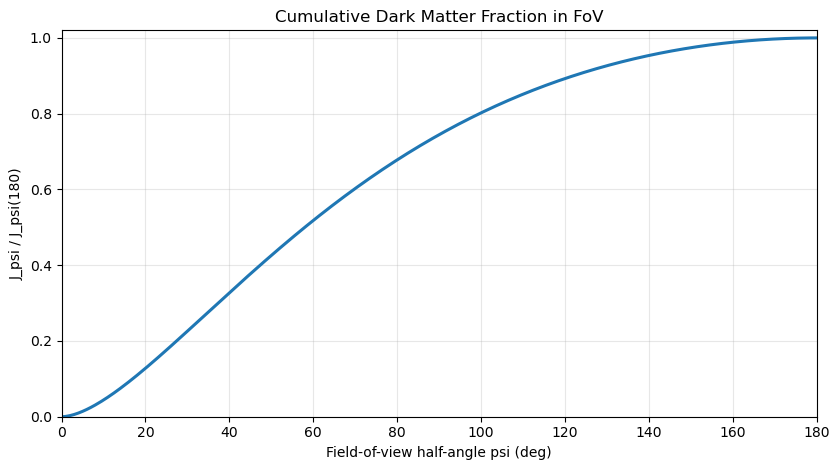

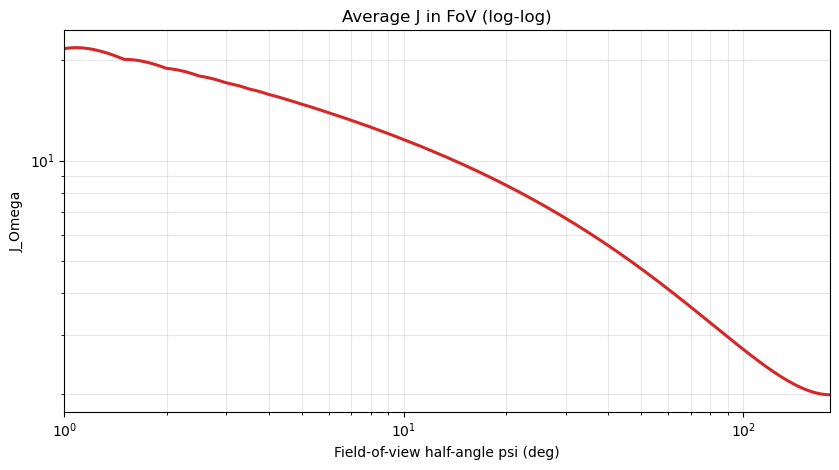

In [5]:
def j_within_fov(psi_max_rad, n_psi=500, n_l=500):
    """Eq. (7): J integrated from 0 to psi_max (field of view centered on GC)."""
    # Integrate J(psi') sin(psi') dpsi' from 0 to psi_max.
    psi_grid = np.linspace(0.0, float(psi_max_rad), int(n_psi))
    integrand = j_factor(psi_grid, n_l=n_l) * np.sin(psi_grid)
    return float(np.trapezoid(integrand, x=psi_grid))


def j_average_fov(psi_max_rad, n_psi=500, n_l=500):
    """Eq. (8): average J over a cone of half-angle psi_max."""
    psi_max = float(psi_max_rad)
    if np.isclose(psi_max, 0.0):
        return j_factor(0.0, n_l=n_l)

    numerator = j_within_fov(psi_max, n_psi=n_psi, n_l=n_l)
    denominator = 1.0 - np.cos(psi_max)
    return numerator / denominator


# Compare with values discussed around Figure 3 in the thesis.
j_180 = j_within_fov(np.pi)
angles_deg = [10, 33, 58, 90, 180]

print(f"J_180 = {j_180:.6f}")
for psi_deg in angles_deg:
    psi_rad = np.deg2rad(psi_deg)
    j_psi = j_within_fov(psi_rad)
    frac = j_psi / j_180
    j_omega = j_average_fov(psi_rad)
    print(f"psi={psi_deg:>3} deg: J_psi/J_180={frac:8.4f}, J_Omega={j_omega:8.4f}")


# ---------- Plot 1: scaled cumulative J_psi / J_psi(180) from psi = 0 to 180 deg ----------
psi_linear_deg = np.linspace(0.0, 180.0, 361)
psi_linear_rad = np.deg2rad(psi_linear_deg)

# First evaluate J(psi) on a dense angle grid, then integrate cumulatively.
j_values_linear = j_factor(psi_linear_rad, n_l=400)
integrand_linear = j_values_linear * np.sin(psi_linear_rad)
dpsi = np.diff(psi_linear_rad)

# Cumulative trapezoid integration without extra dependencies.
j_phi_linear = np.zeros_like(psi_linear_rad)
j_phi_linear[1:] = np.cumsum(0.5 * (integrand_linear[1:] + integrand_linear[:-1]) * dpsi)

j_phi_180 = j_phi_linear[-1]
scaled_j_phi = j_phi_linear / j_phi_180

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(psi_linear_deg, scaled_j_phi, color="tab:blue", lw=2.2)
ax.set_xlim(0.0, 180.0)
ax.set_ylim(0.0, 1.02)
ax.set_xlabel("Field-of-view half-angle psi (deg)")
ax.set_ylabel("J_psi / J_psi(180)")
ax.set_title("Cumulative Dark Matter Fraction in FoV")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ---------- Plot 2: J_Omega from psi = 1 to 180 deg (log-log) ----------
psi_log_deg = np.logspace(np.log10(1.0), np.log10(180.0), 220)
psi_log_rad = np.deg2rad(psi_log_deg)

# Reuse cumulative J_psi values via interpolation, then divide by solid-angle factor.
j_phi_log = np.interp(psi_log_rad, psi_linear_rad, j_phi_linear)
j_omega_log = j_phi_log / (1.0 - np.cos(psi_log_rad))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.loglog(psi_log_deg, j_omega_log, color="tab:red", lw=2.2)
ax.set_xlim(1.0, 180.0)
ax.set_xlabel("Field-of-view half-angle psi (deg)")
ax.set_ylabel("J_Omega")
ax.set_title("Average J in FoV (log-log)")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## Mollweide Projection of J Across the Sky (Figure 4 Style)

This cell evaluates $J(\psi(l,b))$ on a grid of Galactic longitude and latitude and visualizes it in a Mollweide projection.

The optional contours at $\psi=33$ deg and $\psi=58$ deg correspond to the approximate 25% and 50% enclosed-dark-matter fields of view discussed in the thesis text.

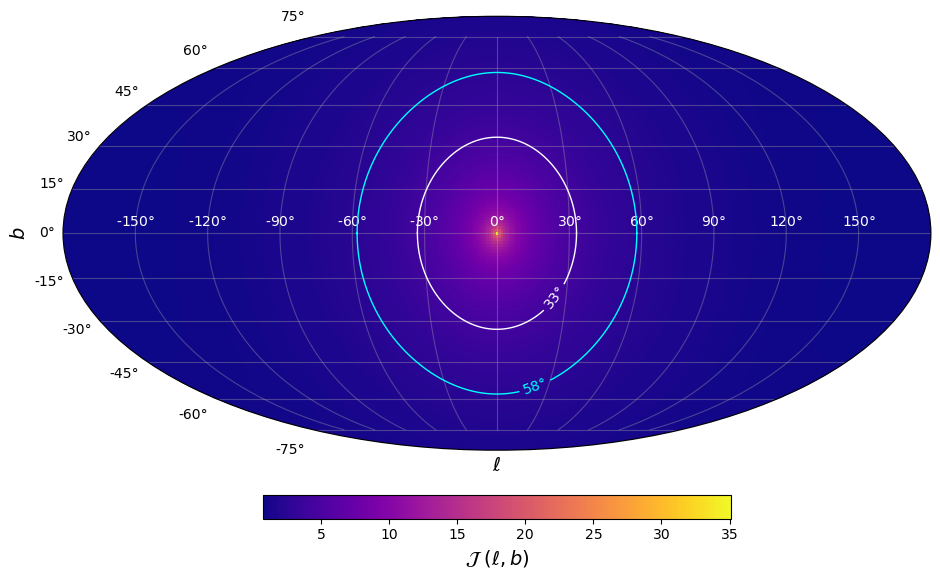

J min = 0.7410, J max = 35.1006


In [23]:
# Sky grid in Galactic coordinates
lon_deg = np.linspace(-180.0, 180.0, 361)
lat_deg = np.linspace(-90.0, 90.0, 181)
lon_rad = np.deg2rad(lon_deg)
lat_rad = np.deg2rad(lat_deg)
lon_grid, lat_grid = np.meshgrid(lon_rad, lat_rad)

psi_grid = psi_from_galactic_coords(lon_grid, lat_grid)
J_map = j_factor(psi_grid, n_l=350)

# Astronomical sky maps often display longitude increasing to the left.
lon_plot = -lon_grid

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={"projection": "mollweide"})
mesh = ax.pcolormesh(lon_plot, lat_grid, J_map, shading="auto", cmap="plasma")

# Add contours corresponding to fixed psi values (in degrees).
cont = ax.contour(
    lon_plot,
    lat_grid,
    np.rad2deg(psi_grid),
    levels=[33.0, 58.0],
    colors=["white", "cyan"],
    linewidths=1.0,
)
ax.clabel(cont, fmt={33.0: r"$33 \degree$", 58.0: r"$58 \degree$"}, inline=True, fontsize=10)

#ax.set_title("Mollweide Projection of Dimensionless J Factor")
ax.grid(True, alpha=0.35)

tick_degrees = np.arange(-150, 180, 30)
ax.set_xticks(np.deg2rad(tick_degrees))
ax.set_xticklabels([f"{d}$\degree$" for d in (tick_degrees)],color='white')
ax.set_xlabel(r"$\ell$",fontsize=14)
ax.set_ylabel(r"$b$",fontsize=14)

cbar = fig.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.08, shrink=0.4)
cbar.set_label(r"$\mathcal{J}~(\ell, b)$",fontsize=14)

plt.tight_layout()
plt.show()

print(f"J min = {J_map.min():.4f}, J max = {J_map.max():.4f}")